# Tarea PCA y Clustering

In [1]:
# Importar las bibliotecas necesarias
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import sys
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.spatial import distance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



sys.path.append('..') 

from FuncionesMineria2 import (plot_varianza_explicada, plot_cos2_heatmap, plot_corr_cos, plot_cos2_bars,
                               plot_contribuciones_proporcionales, plot_pca_scatter, plot_pca_scatter_with_vectors,
                               plot_pca_scatter_with_categories)

## 0. Exploración inicial de los datos

In [2]:
# Cargar el conjunto de datos de pingüinos
penguins = sns.load_dataset('penguins')

# Mostrar las primeras filas del conjunto de datos
print("Primeras filas del conjunto de datos:")
penguins.head()

Primeras filas del conjunto de datos:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# Mostrar información básica sobre el conjunto de datos
print("\nInformación del conjunto de datos:")
penguins.info()


Información del conjunto de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
# Mostrar estadísticas descriptivas
descriptivos_num = penguins.describe().T
descriptivos_num

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


Observamos las filas con NaNs para tratarlos antes de pasar al PCA

In [5]:

penguins[penguins.isna().any(axis=1)]


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


Eliminamos las observaciones con NaNs. En primer lugar, se planteó eliminar solo las filas que tenían más del 50% de valores perdidos, pero debido a que es complicado rellenar una columna como el sexo, se decidió eliminar todas las filas con NaNs presentes. 

In [6]:
penguins = penguins.dropna(axis=0)

Reseteamos índice para tener las observaciones ordenadas

In [7]:
penguins = penguins.reset_index(drop=True)


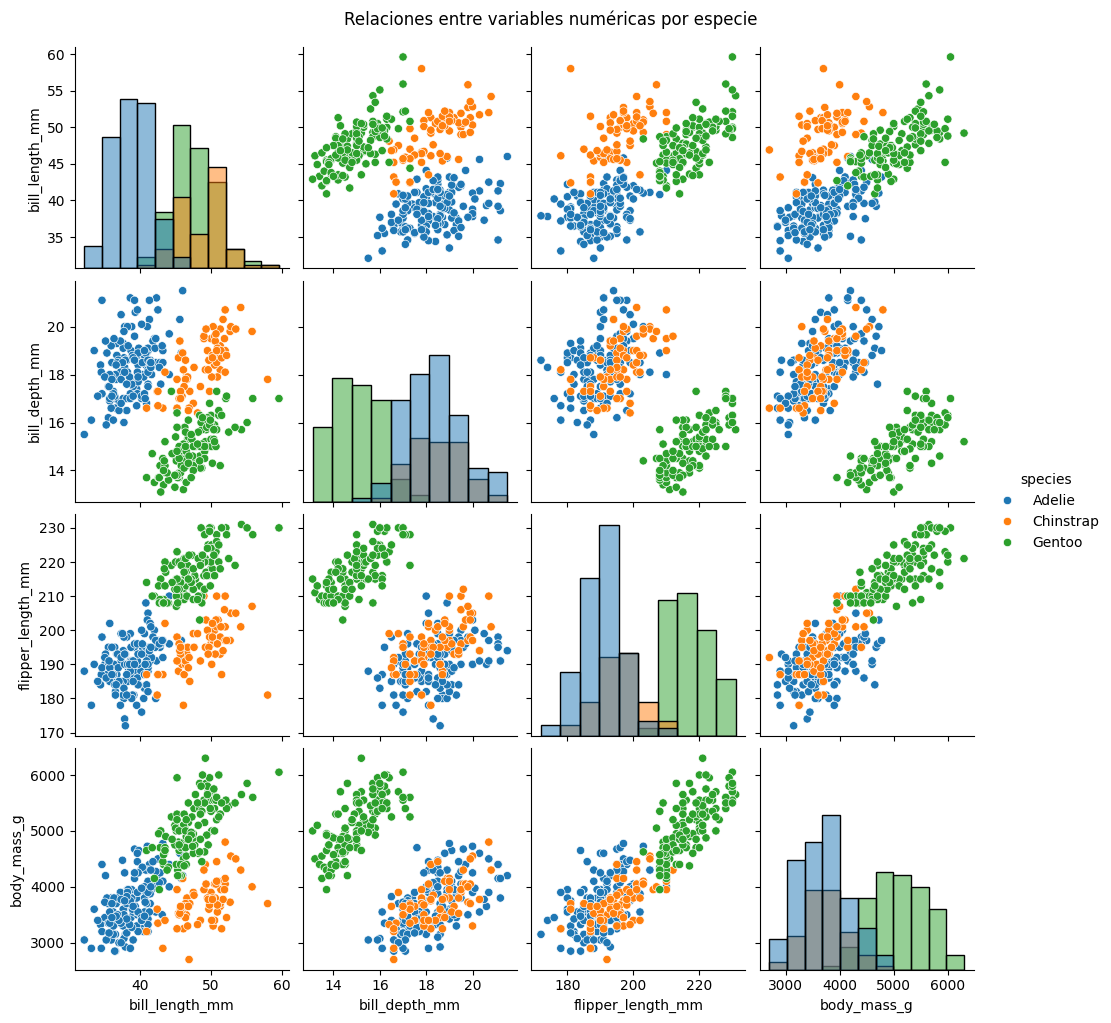

In [8]:
# Crear un conjunto de gráficos de dispersión (pairplot)
sns.pairplot(penguins, hue="species", diag_kind="hist")
plt.suptitle("Relaciones entre variables numéricas por especie", y=1.02)
plt.show()

En este conjunto de gráficos de dispersión, podemos observar la relación entre las variables numéricas y como van apareciendo clusteres o agrupamientos en función de la especie de pingüino. 

También, observamos histogramas que representan las frecuencias de cada variable numérica. 

En este caso, estos datos se están visualizando respecto a la especie (variable categórica). También podríamos visualizarlos respecto a las otras dos variables categóricas: isla y sexo

A continuación, visualizamos la relación entre dos variables categóricas: especie e isla. Observamos como la especie Adelie está presente en todas las islas y como las otras dos especies solo estan presentes en una distinta cada uno.

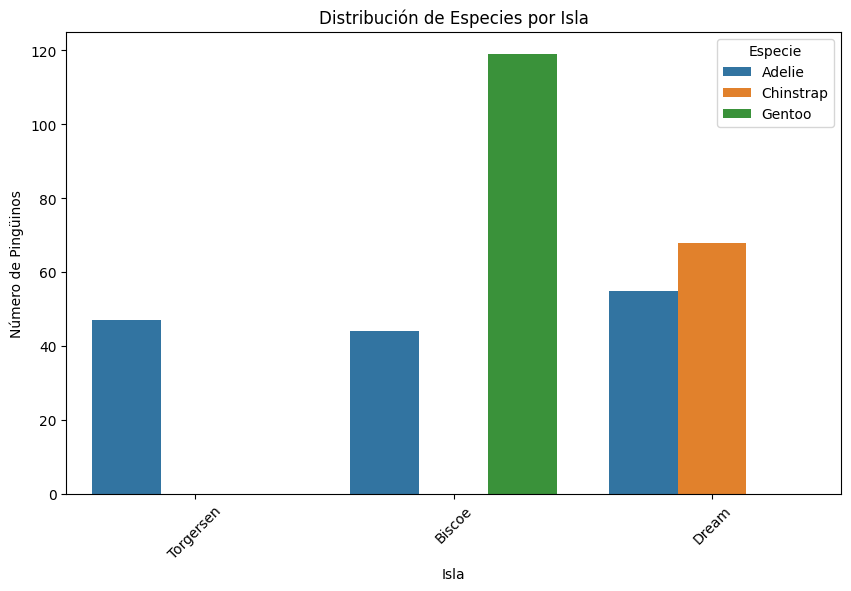

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=penguins, x='island', hue='species')
plt.title('Distribución de Especies por Isla')
plt.xlabel('Isla')
plt.ylabel('Número de Pingüinos')
plt.xticks(rotation=45)
plt.legend(title='Especie')
plt.show()

## 1. Matriz de correlaciones y representación gráfica

A la hora de preparar los datos para la PCA, debemos eliminar las variables categóricas del estudio. 

In [10]:
variables_input = list(penguins.columns)  

# Selecionamos las variables numéricas
numericas_input = penguins.select_dtypes(include = ['int', 'int32', 'int64','float', 'float32', 'float64']).columns

# Selecionamos las variables categóricas
categoricas_input = [variable for variable in variables_input if variable not in numericas_input]

In [11]:
penguins_num = penguins[numericas_input]

Además, debemos estandarizar las variables.  Para la matriz de correlación no es necesario (ya que son datos estandarizados), pero para el resto de fases de la PCA sí. Lo dejamos hecho: 


In [12]:
scaler = StandardScaler()
penguins_num_Z = pd.DataFrame(scaler.fit_transform(penguins_num), columns=penguins_num.columns)

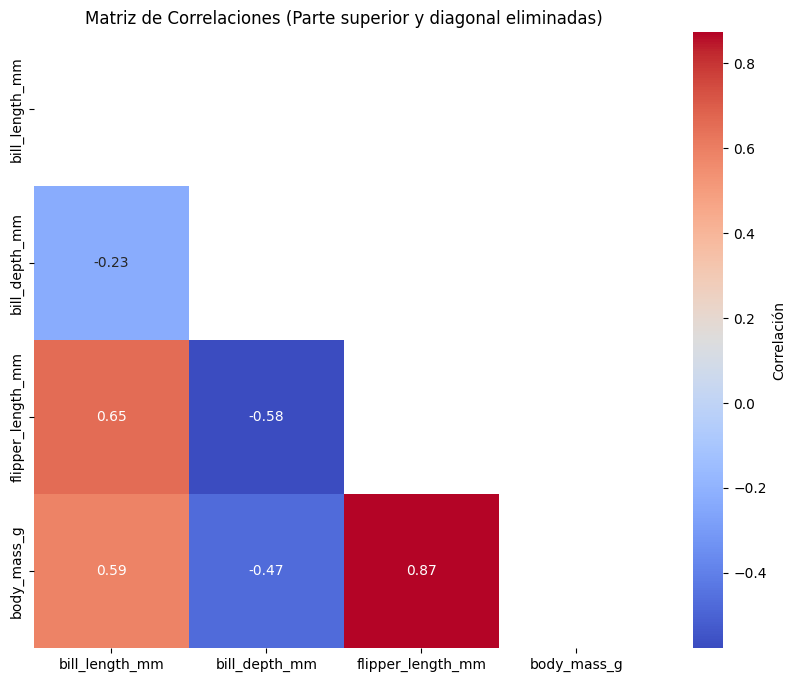

In [13]:
# Calcular la matriz de correlaciones (por defecto se usa Pearson)
corr = penguins_num_Z.corr()

# Crear una máscara para la parte superior (incluyendo la diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Aplicar la máscara: se asignan NaN a la parte superior y a la diagonal
corr_lower = corr.mask(mask)

# Visualizar la matriz resultante con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_lower, annot=True, cmap="coolwarm", cbar_kws={'label': 'Correlación'})
plt.title("Matriz de Correlaciones (Parte superior y diagonal eliminadas)")
plt.show()

Gracias a la matriz de correlación, observamos la presencia de la multicolinealidad entre las variables. Por un lado, de forma directa nos encontramos con una gran relación entre la masa en gramos y la longitud de la aleta en mm. Por otro lado, la mayor correlación inversa se presenta entre la profundidad del pico y la longitud de la aleta. 

En resumen, es un escenario ideal para aplicar Análisis de Componentes Principales

## 2. Análisis de componentes principales 

En primer lugar, vamos a ajustar el modelo PCA con 4 componentes principales, es decir, el máximo permitido para este conjunto de datos ya que es el número de columnas que tiene. El objetivo es descubrir cual es el número de componentes que necesitamos para explicar máxima variabilidad posible del conjunto de datos

In [14]:
pca = PCA(n_components=4)

In [15]:
fit = pca.fit(penguins_num_Z)

In [16]:
autovalores = fit.explained_variance_
var_explicada = fit.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

In [17]:
data = { "Autovalores ": autovalores , "Variabilidad Explicada ": var_explicada
, "Variabilidad Acumulada": var_acumulada}
tabla = pd . DataFrame ( data , index =[ "Componente {} ". format ( i ) for i in range
(1, fit.n_components_ +1)])

In [18]:
tabla

,Autovalores,Variabilidad Explicada,Variabilidad Acumulada
Componente 1,2.753625,0.686339,0.686339
Componente 2,0.780461,0.194529,0.880868
Componente 3,0.369753,0.092161,0.973029
Componente 4,0.108210,0.026971,1.000000


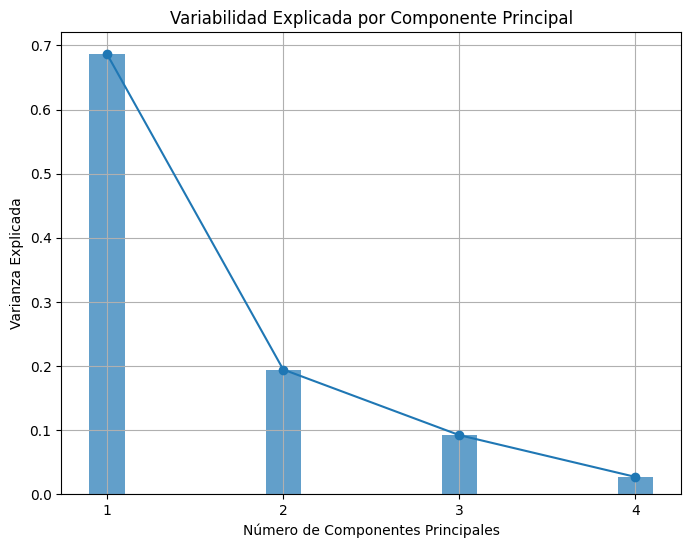

In [19]:
plot_varianza_explicada(var_explicada, fit.n_components_)

Los resutlados muestran cómo la variabilidad viene explicada en un 68% por la primera componente y en un 19% por la segunda. Debido a que entre las dos ya cubrimos el 88% de la variabilidad, se decidió seleccionar estas componentes como las óptimas. Sin embargo, no sería mala idea seleccionar también la tercera, y así lograr un 97%. 




## 3. PCA con el número óptimo de componentes 
Tal y como se especifica en el apartado anterior, se decidió continuar con 2 componentes principales. Por lo tanto, ajustamos en base a ese número y obtenemos los autovectores

In [20]:
pca = PCA(n_components=2)
fit = pca.fit(penguins_num_Z)
              
autovectores = pd.DataFrame(pca.components_.T,
                            columns = ['Autovector de la Comp.Princ. {}'.format(i) for i in range(1, fit.n_components_+1)],
                            index = ['{}_z'.format(variable) for variable in numericas_input])

autovectores       

,Autovector de la Comp.Princ. 1,Autovector de la Comp.Princ. 2
bill_length_mm_z,0.453753,0.600195
bill_depth_mm_z,-0.399047,0.796170
flipper_length_mm_z,0.576825,0.005788
body_mass_g_z,0.549675,0.076464


Lo que se observa arriba es la matriz de autovectores que se utiliza para pasar la matriz de datos al espacio de las componentes principales

A continuación, calculamos esta representación de los datos en el espacio de las componentes principales (es decir, las propias componentes principales) En vez de solo ajustar el conjunto de datos (para obtener autovalores y autovectores), utilizamos fit.transform para transformarlos. 



In [21]:
# Calculamos las dos primeras componentes principales para cada observación de datos
resultados_pca = pd.DataFrame(fit.transform(penguins_num_Z),
                              columns=['Componente {}'.format(i) for i in range(1, fit.n_components_+1)],
                              index=penguins_num_Z.index)

Y las añadimos al dataframe estandarizado para calcular la correlación entre las componentes principales y las columnas antiguas

In [22]:
# Añadimos las componentes principales a la base de datos estandarizada.
penguins_z_cp = pd.concat([penguins_num_Z, resultados_pca], axis=1)
display(penguins_z_cp)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Componente 1,Componente 2
0,-0.896042,0.780732,-1.426752,-0.568475,-1.853593,0.032069
1,-0.822788,0.119584,-1.069474,-0.506286,-1.316254,-0.443527
2,-0.676280,0.424729,-0.426373,-1.190361,-1.376605,-0.161230
3,-1.335566,1.085877,-0.569284,-0.941606,-1.885288,-0.012351
4,-0.859415,1.747026,-0.783651,-0.692852,-1.919981,0.817598
...,...,...,...,...,...,...
328,0.587352,-1.762145,0.931283,0.892957,1.997716,-0.976771
329,0.514098,-1.457000,1.002739,0.799674,1.832651,-0.784510
330,1.173384,-0.744994,1.502928,1.919069,2.751505,0.266556
331,0.221082,-1.202712,0.788372,1.234995,1.713854,-0.725875


Ahora, obtenemos las correlaciones entre columnas del dataset y las componentes principales. También, la métrica cosenos al cuadrado para ver el porcentaje de cada variable explicado por cada componente.

In [23]:
# Guardamos el nombre de las variables del archivo conjunto (variables y componentes).
variables_cp = penguins_z_cp.columns

# Calculamos las correlaciones y seleccionamos las que nos interesan (variables contra componentes).
#comparamos dataframe estandarizado con componentes principales. Por eso se eligen estos datasets y no penguins_z_cp
correlacion = pd.DataFrame(np.corrcoef(penguins_num_Z.T, resultados_pca.T), 
                           
                           index = variables_cp, columns = variables_cp)

n_variables = fit.n_features_in_
penguins_correlaciones_con_cp = correlacion.iloc[:fit.n_features_in_, fit.n_features_in_:]
display(penguins_correlaciones_con_cp)

,Componente 1,Componente 2
bill_length_mm,0.751829,0.529438
bill_depth_mm,-0.661186,0.702309
flipper_length_mm,0.955748,0.005106
body_mass_g,0.910762,0.067449


In [24]:
cos2 = penguins_correlaciones_con_cp**2
cos2

,Componente 1,Componente 2
bill_length_mm,0.565247,0.280304
bill_depth_mm,0.437167,0.493237
flipper_length_mm,0.913454,0.000026
body_mass_g,0.829488,0.004549


#### Apartado 3a

Observamos como la componente 1, aunque recoge información de todas las variables, explica las variables relacioadas con la longitud de la aleta y el peso del animal casi en su totalidad.

Por otro lado, estas dos variables no se encuentran nada representadas en la componente 2. Parece ser que esta componente explica casi el resto de la variabilidad de las características del pico. 

En los próximos gráficos observamos los resultados de una forma más visual

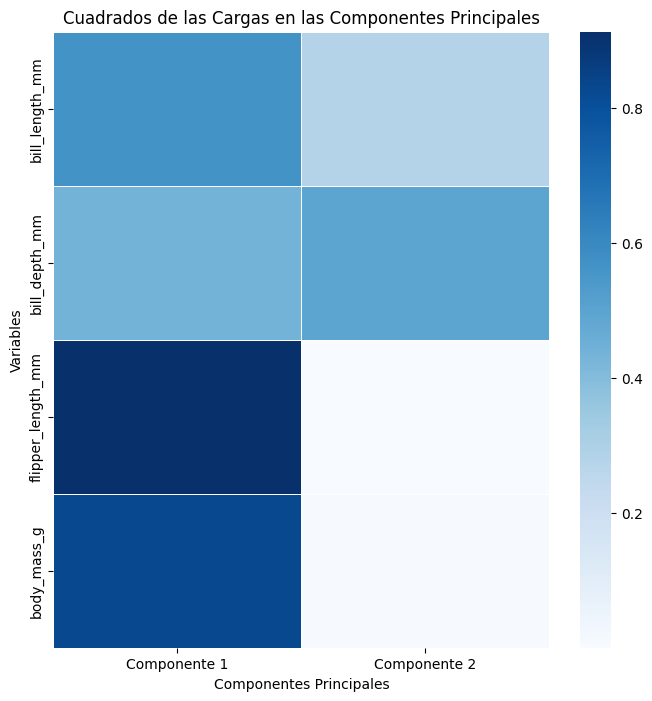

In [25]:
plot_cos2_heatmap(cos2)

g:\Mi unidad\Inteligencia Artificial\Máster IA\Semanas 9 a 13 - Minería de Datos y Modelización Predictiva\Tarea_mineria_PCA_Clustering\..\FuncionesMineria2.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = cmap(sum_cos2[k])


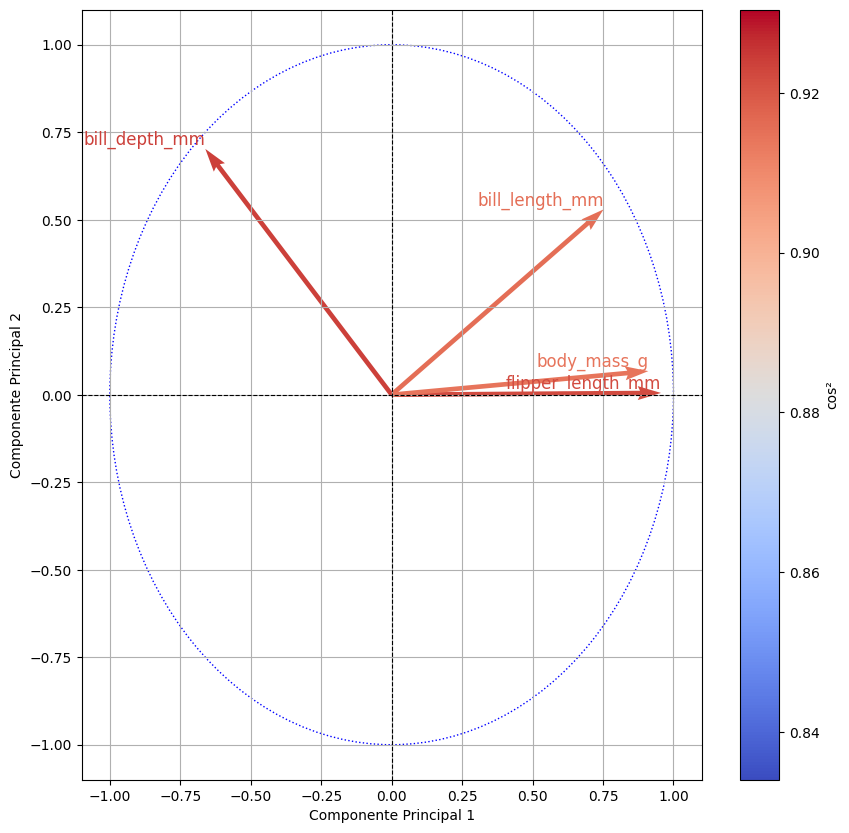

In [26]:
plot_corr_cos(fit.n_components, penguins_correlaciones_con_cp)

### Apartado 3b 
A continuación, vamos a observar las coordenadas de los pinguinos en el nuevo espacio 
de componentes principales. Los ejes son las componentes y los puntos son las observaciones
de pinguinos. Además, vamos a diferenciarlos por especie para responder a la pregunta del apartado: ¿Qué especies destacan más en cada componente?

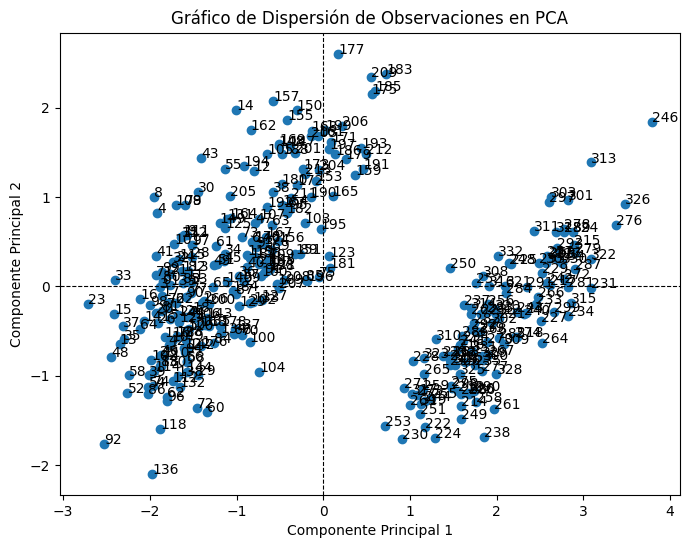

In [27]:
plot_pca_scatter(pca, penguins_num_Z, fit.n_components)

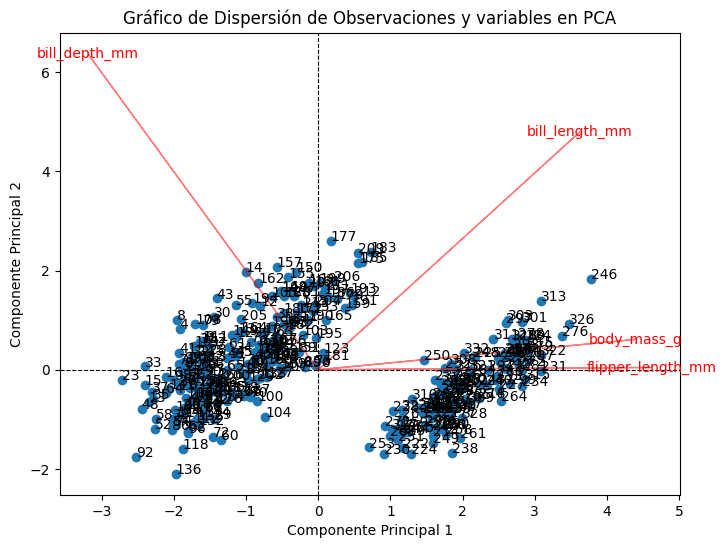

In [28]:
plot_pca_scatter_with_vectors(pca, penguins_num_Z, fit.n_components, fit.components_)

In [29]:
# Añadimos la variable categórica "species" a los datos
penguins_num_categ_z = pd.concat([penguins_z_cp, penguins["species"]], axis=1)  


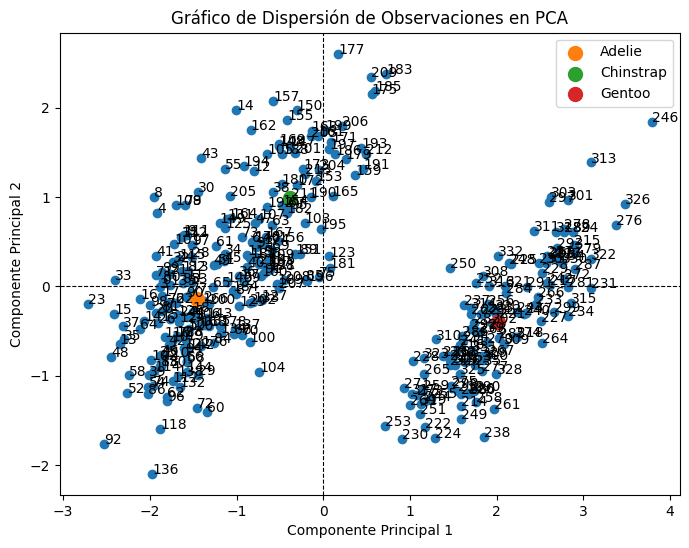

In [30]:
plot_pca_scatter_with_categories(penguins_num_categ_z, resultados_pca , fit.n_components, "species")

Tras observar los gráficos, vemos como la especie Gentoo destaca mucho más que las otras dos en la componente 2, la cual está más relacionada con el peso del animal y con la longitud de las aletas. 

Respecto a la componente prinicpal 1, la que más destaca es la especie Chinstrap. Esta componente recogía información en general de las 4 medidas

### Apartado 3c
Podemos crear un índice a partir de la primera componente principal. Esta componente recoge la mayor variabilidad posible y además de todas las variables numéricas del dataframe. 




Para ello, podemos agrupar por especie, calculando el valor medio de la componente 1 para cada una de estas.

In [31]:
# Calcular el índice: valor medio de PC1 para cada especie
indices_por_especie = penguins_num_categ_z.groupby('species')['Componente 1'].mean()
indices_por_especie

species
Adelie      -1.459721
Chinstrap   -0.388600
Gentoo       2.012976
Name: Componente 1, dtype: float64

El índice obtenido nos permite diferenciar cada una de las especies bastante bien. El índice para Adelie es muy negativo y diferente del de la especie Gentoo. Esto representa la gran diferencia y distancia que había entre sus centroides en el espacio de componentes principales. Luego, la especie Chinstrap tiene un índice entre medias de ambos, al igual que su posición en el espacio de componentes.

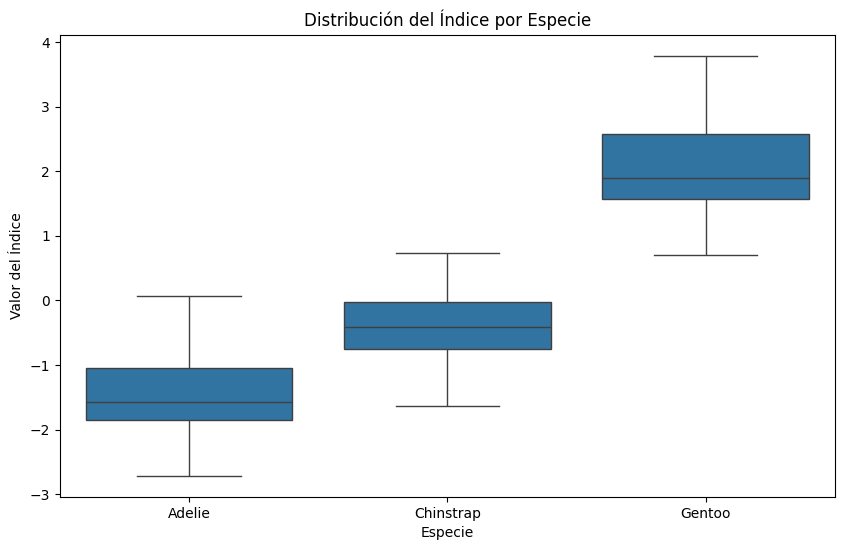

In [32]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=penguins_num_categ_z, x='species', y='Componente 1')
plt.title('Distribución del Índice por Especie')
plt.xlabel('Especie')
plt.ylabel('Valor del Índice')
plt.show()

Si nos fijamos en la gráfica con los centroides del apartado3b, no podríamos elegir la componente principal 2 ya que los valores de las especies Adelie y Gentoo estarían muy cerca. Utilizando la componente 1, se encuentran más separados, creando así el índice de antes.

## 4. Determinación del número de clusters. Método jerárquico

In [33]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


En primer lugar, tenemos que preprocesar los datos transformando: 
- las variables numéricas estandarizándolas
- las variables categóricas convirtíendolas en dummies

In [34]:
# Seleccionar las variables numéricas y categóricas
numericas_input = penguins.select_dtypes(include = ['int', 'int32', 'int64','float', 'float32', 'float64']).columns
categoricas_input = [variable for variable in penguins.columns if variable not in numericas_input]

# Crear un objeto ColumnTransformer
encoder = OneHotEncoder(drop='first')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas_input),
        ('cat', encoder, categoricas_input)
    ])

# Ajustar y transformar los datos
penguins_prep = preprocessor.fit_transform(penguins)

In [35]:

# Calculate the pairwise Euclidean distances
distance_matrix = distance.cdist(penguins_prep, penguins_prep, 'euclidean')


A pesar de la gran cantidad de observaciones, lo cual dificulta la visibilidad de la figura, podemos observar unos 3 grupos. Nos vamos haciendo a la idea del k-óptimo que obtendremos del dendograma

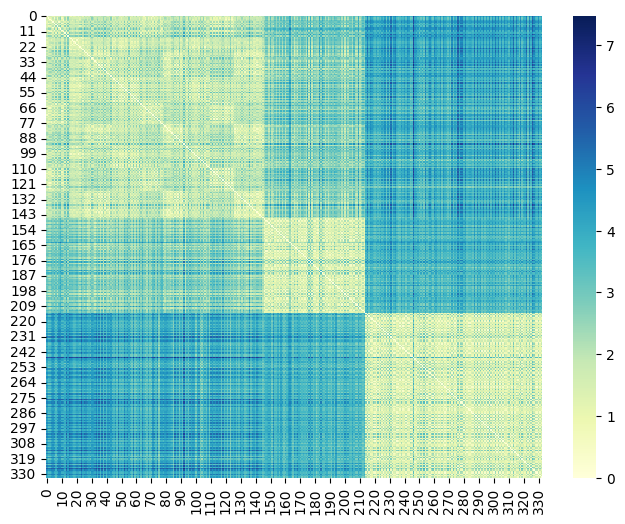

In [36]:
plt.figure(figsize=(8, 6))
df_std_distance = pd.DataFrame(distance_matrix, index = penguins.index, columns = penguins.index)
sns.heatmap(df_std_distance, annot=False, cmap="YlGnBu", fmt=".1f")
plt.show()

C:\Users\aviguera\AppData\Local\Temp\ipykernel_15064\2846840433.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(df_std_distance, method='ward')


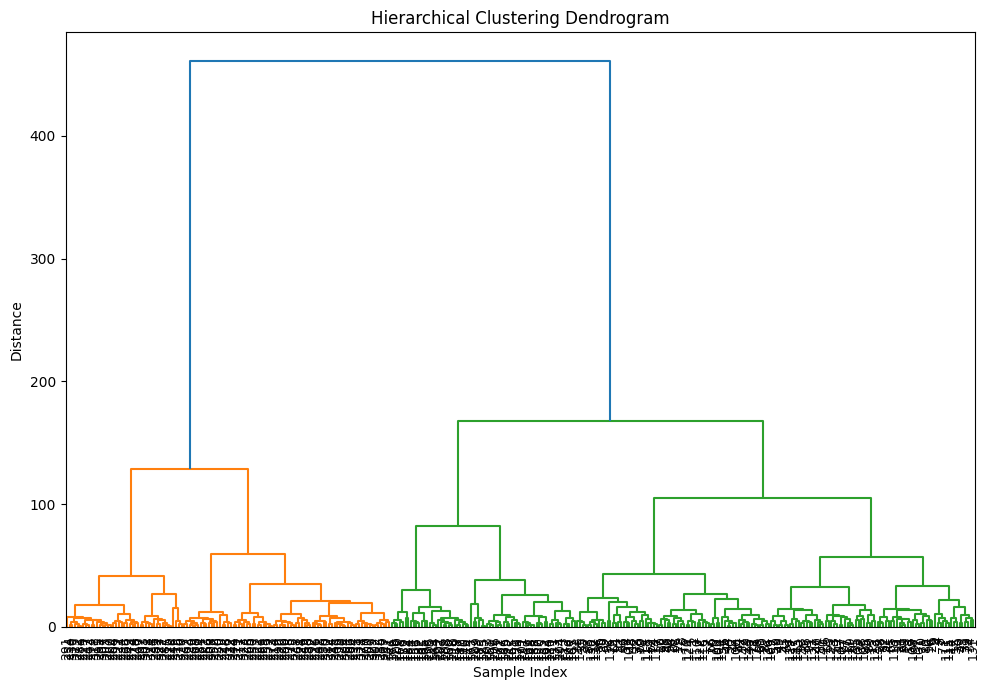

In [37]:

# Calculate the linkage matrix
linkage_matrix = sch.linkage(df_std_distance, method='ward')  

# Create the dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(
    linkage_matrix,
    labels=penguins.index,
    leaf_font_size=9,
    leaf_rotation=90
)

# Add title and adjust layout
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Tras observar el dendograma, podemos observar que hay 2 grupos muy diferenciados. Es algo que también se veía en el PCA. Además, se realiza una subdivisión en 3 o 4 clústeres. Es decir, podría partir de k=3 o de k=4. 

Debido a la información extra que proporciona la representación visual de la matriz de distancias, se decidió a proseguir con k=3. 

## 5. Agrupamiento K-means (método no jerárquico)

Tras conocer un posible k óptimo, es el momento de obtener los grupos formados

In [38]:

# Set the number of clusters (k=4)
k = 3

# Initialize the KMeans model
kmeans = KMeans(n_clusters=k, random_state=0)

# Fit the KMeans model to your standardized data
kmeans.fit(penguins_prep)

# Get the cluster labels for your data
kmeans_cluster_labels = kmeans.labels_

print(kmeans_cluster_labels)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


Tras obtener las etiquetas del clustering, vamos a reducir las dimensiones a un espacio de 2 para observar los agrupamientos

In [39]:
from sklearn.decomposition import PCA

# Assuming 'df' is your original DataFrame with data
# 'cluster_assignments' contains cluster assignments

# Step 1: Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(penguins_prep)

# Create a new DataFrame for the 2D principal components
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

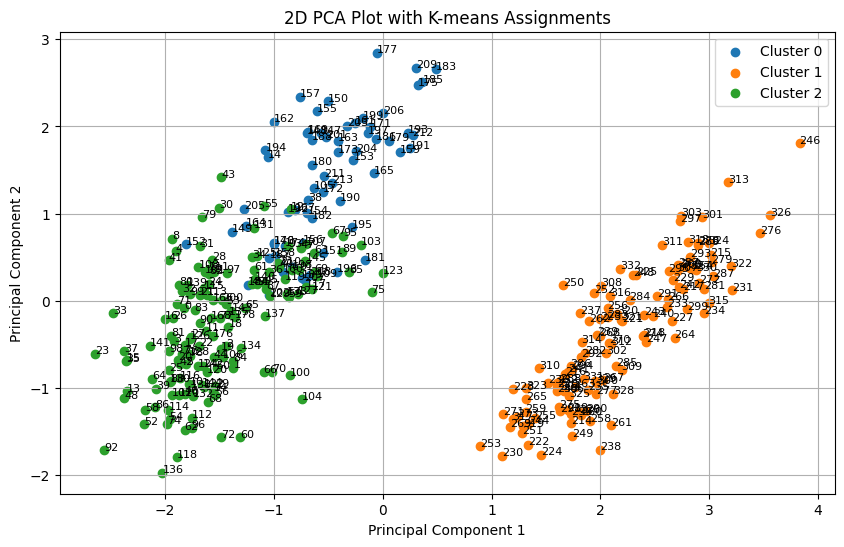

In [40]:
# Step 2: Create a scatter plot with colors for clusters
plt.figure(figsize=(10, 6))

# Loop through unique cluster assignments and plot data points with the same color
for cluster in np.unique(kmeans_cluster_labels):
    plt.scatter(df_pca.loc[kmeans_cluster_labels == cluster, 'PC1'],
                df_pca.loc[kmeans_cluster_labels == cluster, 'PC2'],
                label=f'Cluster {cluster}')
# Add labels to data points
for i, row in df_pca.iterrows():
    plt.text(row['PC1'], row['PC2'], str(penguins.index[i]), fontsize=8)

plt.title("2D PCA Plot with K-means Assignments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

Como se puede observar, hay un total de 3 grupos bastante diferenciados obtenidos a través del clustering. Vamos a aplicar ahora el método del codo para observar si ese k=3 es el óptimo o resulta que hay otro mejor.

In [41]:
#Create an array to store the WCSS values for different values of K:
wcss = []

for k in range(1, 11):  # You can choose a different range of K values
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(penguins_prep)
    wcss.append(kmeans.inertia_)  # Inertia is the WCSS value

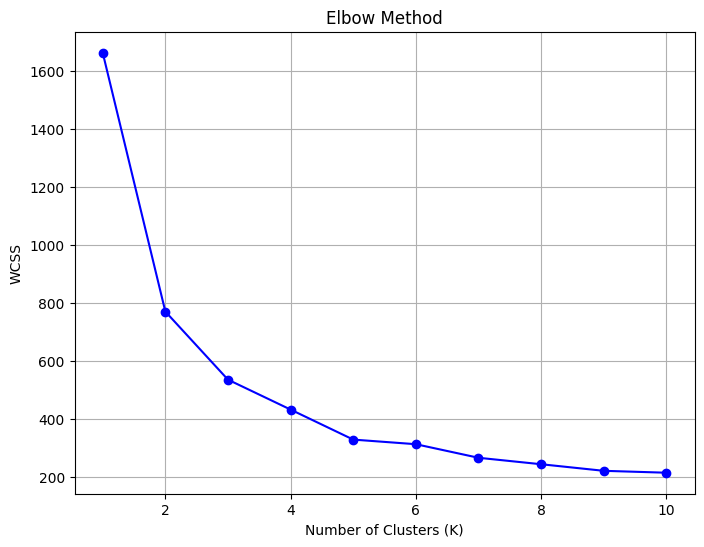

In [42]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

El método del codo muestra que la prinicpal bajada del valor de WCSS se logra con los 3 primeros agrupamientos. Podríamos estirar hasta 5 agrupamientos pero a partir de ahí no merece la pena aumentar el número de clusters. 

Vamos a probar con k = 5

In [43]:
# Set the number of clusters (k=4)
k = 5

# Initialize the KMeans model
kmeans = KMeans(n_clusters=k, random_state=0)

# Fit the KMeans model to your standardized data
kmeans.fit(penguins_prep)

# Get the cluster labels for your data
kmeans_cluster_labels = kmeans.labels_

print(kmeans_cluster_labels)

[3 2 2 2 3 2 3 2 3 3 2 2 3 2 3 2 3 2 3 2 2 3 2 2 3 2 2 2 3 2 3 3 2 2 3 2 3
 2 3 2 3 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3
 2 3 2 3 2 3 3 2 3 2 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 3 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 2 2 2 2 3 3 2 2 3 2 3 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 4 1 4 1 1 4 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 1 4 4 1 4 1 1 4 1 1 4 4 1 4 1 4 1 4 1 4 1 4 1 1 4
 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 1 4 1 4 1 1 4 4 1 4 1 4 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 1 4 4 1 4 1 4 1 1 4 1 4 1 4 1 4 1 4 1 1 4 4 1 4 1]


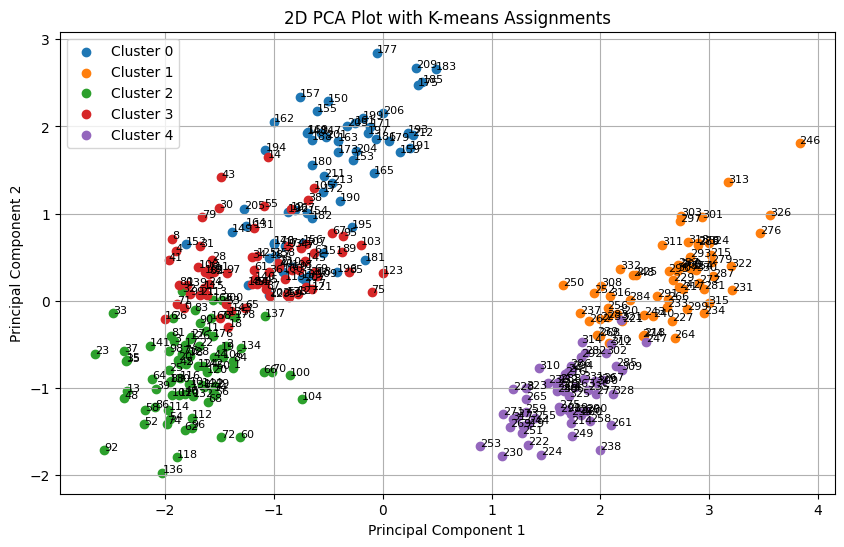

In [44]:
# Step 2: Create a scatter plot with colors for clusters
plt.figure(figsize=(10, 6))

# Loop through unique cluster assignments and plot data points with the same color
for cluster in np.unique(kmeans_cluster_labels):
    plt.scatter(df_pca.loc[kmeans_cluster_labels == cluster, 'PC1'],
                df_pca.loc[kmeans_cluster_labels == cluster, 'PC2'],
                label=f'Cluster {cluster}')
# Add labels to data points
for i, row in df_pca.iterrows():
    plt.text(row['PC1'], row['PC2'], str(penguins.index[i]), fontsize=8)

plt.title("2D PCA Plot with K-means Assignments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

Parece ser que k=5 no es un mal número de grupos. Sinembargo, los clústers 3 y 0 se mezclan mucho y no perece la pena aumentar en 2 el número de grupos para estos resultados. 

Por lo tanto, se toma k=3 como número óptimo de grupos.

## 6. Evaluación: método de la silueta

El método de la silueta permite obtener una validación del número de clusters escogido. El score de la silueta es un valor entre -1 y 1. Una puntuación cercana a 1 indica que la observación coincide bien con su propio grupo y no coincide con los grupos vecinos.

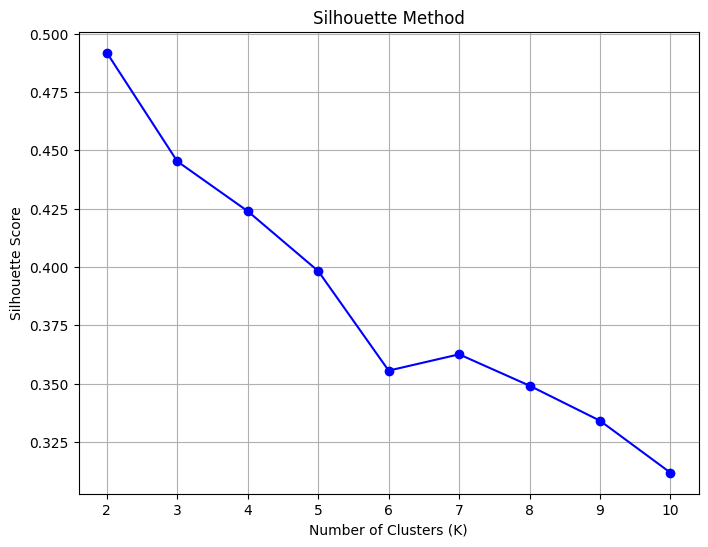

In [45]:
#Create an array to store silhouette scores for different values of K

silhouette_scores = []

#Run K-means clustering for a range of K values and calculate the silhouette score for each K:

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(penguins_prep)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(penguins_prep, labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

En este caso, parece ser que el k=2 es el mejor resultado. Sin embargo, es un agrupamiento muy simple para el conjunto de datos. El próximo es k = 3, que fue el número óptimo elegido. 

Como la caída del score de la silueta sigue presente en los próximos valores de k, se puede confirmar que elegir k = 3 fue una buena elección y que no merece la pena aumentar más su valor. 

## 7. Comparación entre Jerárquico y K-means

Por un lado, ambos métodos identifican grupos que se corresponden bastante bien con las especies reales. 

Ambos logran dividir de forma definida las observaciones en 3. 

Las diferencias están más centradas a nivel teórico. El método jerárquico de obtener un dendograma no requiere de un número de clusters definido para ejecutarse. Es más, suele utilizarse este método para hacerse a la idea del número de clusters a elegir.

A partir de este número elegido (aunque también podría utilizarse el método del codo), se pasa al algoritmo K-means para obtener la división por grupos definitiva. Es decir, obtener las etiquetas que clasifican las observaciones. 

En resumen, ambos algoritmos son dos partes de un proceso que tiene como objetivo encontrar la división por grupos óptima para el conjunto de datos de estudio

## 8. Proporciona una interpretacion de los grupos. 
¿Qué representan los grupos identificados en el contexto de las especies de pinguinos? ¿Existen patrones o tendencias significativas? 

Los grupos representan exactamente las especies de pinguinos. Si comparamos los resultados del PCA y del clústering, podemos observar como los centroides de las especies se encuentran definidos por los grupos de los clústers. Es decir, 
el cluster 0 correpsonde a la especie Chinstrap, el 1 a la especie Gentoo y el 2 a la espcie Adelie

Entonces, la especie del animal influye mucho en el grupo en el que es clasificado. La etiqueta podría ser la especie

## Resume tus hallazgos y concluye el an alisis. Discute limitaciones o desafíos encontrados durante el proceso de agrupamiento. 

Tal y como se ha comentado en el apartado anterior, el análisis de componentes principales y el clústering han derivado en el siguiente resultado: Las especies tienen una influencia muy significativa en el agrupamiento de las observaciones. 

Durante el proceso de agrupamiento, tuve el siguiente desafío. Dudé sobre si incluir las variables categóricas en el estudio. Es decir, la especie, la isla y el sexo del animal. Sin embargo, tras realizar una prueba rápida con el código, eliminando las columnas categóricas, el resultado fue muy similar. Es decir, a pesar de eliminar las varaibles categóricas como la especie, la división de grupos seguía siendo la misma.

Por lo tanto, la información que ofrece la variable categórica especie y las variables numéricas parece ser la misma. Es decir, los pinguinos de diferente especie tienen distintas propiedades anatómicas que los hace diferentes y por lo tanto ser clasificados en grupos distintos. 
